# Prompt Chaining Sequential Workflow

In [7]:
# libraries
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_groq.chat_models import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
from IPython.display import Image
import os

In [5]:
# load api key
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [10]:
# load LLM model
llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0,
    max_tokens = None
)

In [12]:
# define state
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str

In [11]:
# define outline function
def generate_outline(state: BlogState) -> BlogState:
    topic = state["topic"]
    prompt = f"Generate an detailed outline of this topic: {topic}"

    outline = llm.invoke(prompt).content
    state["outline"] = outline

    return state

In [13]:
# define blog function
def generate_blog(state: BlogState) -> BlogState:
    topic = state["topic"]
    outline = state["outline"]
    prompt = f"Generate a detailed blog for this topic {topic} and outline {outline}"
    
    content = llm.invoke(prompt).content
    state["content"] = content
    
    return state

In [14]:
# define graph
graph = StateGraph(BlogState)

# define nodes
graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_blog", generate_blog)

# define edges
graph.add_edge(START, "generate_outline")
graph.add_edge("generate_outline", "generate_blog")
graph.add_edge("generate_blog", END)

# compile
workflow = graph.compile()

In [16]:
# execute
initial_state = {
    "topic": "Large Language Models"
}
final_state = workflow.invoke(initial_state)
print(final_state["content"])

**Large Language Models: A Comprehensive Overview**

**Introduction**

Large Language Models (LLMs) have revolutionized the field of natural language processing (NLP) and artificial intelligence (AI). These models are designed to process and understand human language, enabling applications such as language translation, text summarization, and dialogue systems. In this blog, we will delve into the world of LLMs, exploring their architecture, training, applications, evaluation, challenges, and future directions.

The concept of LLMs dates back to the early 2000s, when researchers began exploring the use of neural networks for NLP tasks. However, it wasn't until the introduction of the Transformer architecture in 2017 that LLMs started to gain significant attention. Since then, LLMs have become a crucial component of many NLP systems, with applications in areas such as sentiment analysis, named entity recognition, and machine translation.

**Architecture and Components**

LLMs are based o

In [19]:
print(final_state["topic"])

Large Language Models


In [20]:
print(final_state["outline"])

Here is a detailed outline of the topic "Large Language Models":

**I. Introduction**

* Definition of Large Language Models (LLMs)
* Brief history and evolution of LLMs
* Importance of LLMs in natural language processing (NLP) and artificial intelligence (AI)

**II. Architecture and Components**

* Overview of the architecture of LLMs
* Components of LLMs:
	+ Encoder: tokenization, embedding, and encoding
	+ Decoder: decoding, generation, and output
	+ Attention mechanism: self-attention, cross-attention, and attention weights
	+ Transformer architecture: encoder-decoder structure, self-attention, and feed-forward neural networks (FFNNs)
* Other components: embedding layers, positional encoding, and layer normalization

**III. Training and Optimization**

* Training objectives: masked language modeling, next sentence prediction, and language translation
* Optimization algorithms: stochastic gradient descent (SGD), Adam, and Adagrad
* Hyperparameter tuning: learning rate, batch size, a

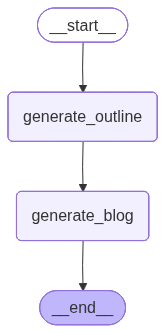

In [17]:
# check graph structure
Image(workflow.get_graph().draw_mermaid_png())